---
#### Import All Libraries

In [82]:
# IMPORTS 
# pandas       → data loading, manipulation, groupby operations
# numpy        → numerical computation, log transforms, IQR math
# matplotlib   → all charts and visualisations
# seaborn      → statistical plots (heatmap, boxplot, violin)
# hashlib      → SHA-256 UUID for anonymisation (privacy layer)
# re           → regex for PII scrubbing from comments
# warnings     → suppress minor sklearn/pandas warnings for clean output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import hashlib
import re
import warnings
warnings.filterwarnings('ignore')

# Chart styling — consistent across all plots in this notebook
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
sns.set_palette("husl")

import os
os.makedirs('../data',   exist_ok=True)
os.makedirs('../charts', exist_ok=True)

print(" All libraries imported")



 All libraries imported


---
## Cell 2 — Load Raw Dataset

In [83]:
#  LOAD DATASET 

RAW_PATH = "../data/RateMyProfessor_Sample data.csv"
df_raw   = pd.read_csv(RAW_PATH)

print("=" * 60)
print("  RAW DATASET — INITIAL SNAPSHOT")
print("=" * 60)
print(f"  Total rows    : {df_raw.shape[0]:,}")
print(f"  Total columns : {df_raw.shape[1]}")
print("=" * 60)
print()
print("Preview (first 3 rows):")
display(df_raw.head(3))


  RAW DATASET — INITIAL SNAPSHOT
  Total rows    : 20,000
  Total columns : 51

Preview (first 3 rows):


,professor_name,school_name,department_name,local_name,state_name,year_since_first_review,star_rating,take_again,diff_index,tag_professor,...,lots_of_homework,accessible_outside_class,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline
0,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
1,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
2,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0


---
#### Full Column Audit

In [84]:
# ─── CELL 3: COLUMN AUDIT ───────────────────────────────────────────────────
# Before touching the data, we audit EVERY column.
# For each column we document: dtype, missing %, and DECISION (keep/drop).
# This audit is our official record of why each column was handled.

print(f"{'#':<4} {'Column':<35} {'Type':<12} {'Nulls':>6} {'Miss%':>6}  Decision")
print("─" * 85)

col_decisions = {
    # PII — drop (project privacy layer requires this)
    'professor_name'    : ('DROP',  'PII — direct identifier'),
    'school_name'       : ('DROP',  'PII — institutional identifier'),
    'local_name'        : ('DROP',  'US city — irrelevant to Indian project'),
    'state_name'        : ('DROP',  'US state — irrelevant to Indian project'),
    'name_onlines'      : ('DROP',  'Name variant field — PII'),
    'name_not_onlines'  : ('DROP',  'Name variant field — PII'),
    # >80% missing — cannot be reliably filled
    'take_again'        : ('DROP',  '85.0% missing — unfillable'),
    'would_take_agains' : ('DROP',  '87.1% missing — unfillable'),
    'grades'            : ('DROP',  '83.5% missing — unfillable'),
    'attence'           : ('DROP',  '80.0% missing — unfillable'),
    'for_credits'       : ('DROP',  '79.7% missing — unfillable'),
    # Redundant / low signal
    
    'race'              : ('DROP',  'Demographic — not used in NLP pipeline'),
    'asian'             : ('DROP',  'Race proportion — not used'),
    'hispanic'          : ('DROP',  'Race proportion — not used'),
    'nh_black'          : ('DROP',  'Race proportion — not used'),
    'nh_white'          : ('DROP',  'Race proportion — not used'),
    'gender'            : ('DROP',  'Mostly unknown — low signal for NLP task'),
    # KEEP — core signal
    'student_star'      : ('KEEP',  'TARGET LABEL for sentiment model'),
    'star_rating'       : ('KEEP',  'Aggregated rating — key feature'),
    'diff_index'        : ('KEEP',  'Difficulty signal — key feature'),
    'student_difficult' : ('KEEP',  'Per-review difficulty perception'),
    'comments'          : ('KEEP',  'NLP INPUT — core text for sentiment model'),
    'word_comment'      : ('KEEP',  'Comment length feature'),
    'IsCourseOnline'    : ('KEEP',  'Delivery mode feature'),
    'year_since_first_review': ('KEEP', 'Professor experience proxy'),
    'num_student'       : ('KEEP',  'Review volume indicator'),
    'post_date'         : ('KEEP',  'Time-based trend feature'),
    'help_useful'       : ('KEEP',  'Peer helpfulness signal'),
    'help_not_useful'   : ('KEEP',  'Peer helpfulness signal'),
}
# All 20 tag columns → KEEP
tags = ['gives_good_feedback','tag_professor','caring','respected','participation_matters',
        'clear_grading_criteria','skip_class','amazing_lectures','inspirational',
        'tough_grader','hilarious','get_ready_to_read','lots_of_homework',
        'accessible_outside_class','lecture_heavy','extra_credit',
        'graded_by_few_things','group_projects','test_heavy',
        'so_many_papers','beware_of_pop_quizzes']
for t in tags:
    col_decisions[t] = ('KEEP', 'Binary tag — structured sentiment signal')

keep_count = drop_count = 0
for i, col in enumerate(df_raw.columns, 1):
    nulls = df_raw[col].isnull().sum()
    pct   = nulls / len(df_raw) * 100
    dec, reason = col_decisions.get(col, ('KEEP', 'Default keep'))
    marker = '✓' if dec == 'KEEP' else '✗'
    color  = ''
    print(f"{i:<4} {col:<35} {str(df_raw[col].dtype):<12} {nulls:>6,} {pct:>5.1f}%  {marker} {dec} — {reason}")
    if dec == 'KEEP': keep_count += 1
    else: drop_count += 1

print()
print(f"  Total KEEP : {keep_count}")
print(f"  Total DROP : {drop_count}")
print(f"  51 → {keep_count} columns after cleaning")


#    Column                              Type          Nulls  Miss%  Decision
─────────────────────────────────────────────────────────────────────────────────────
1    professor_name                      str               0   0.0%  ✗ DROP — PII — direct identifier
2    school_name                         str               0   0.0%  ✗ DROP — PII — institutional identifier
3    department_name                     str               0   0.0%  ✓ KEEP — Default keep
4    local_name                          str               0   0.0%  ✗ DROP — US city — irrelevant to Indian project
5    state_name                          str               0   0.0%  ✗ DROP — US state — irrelevant to Indian project
6    year_since_first_review             int64             0   0.0%  ✓ KEEP — Professor experience proxy
7    star_rating                         float64           0   0.0%  ✓ KEEP — Aggregated rating — key feature
8    take_again                          str          17,002  85.0%  ✗ DROP — 85.0% 

---
#### Drop PII Columns


In [85]:
# ─── CELL 4: DROP PII COLUMNS ──────────────────────────────────────────────
# The EDU-FEED pipeline document states:
#   "No student name, ID, roll number, email, section, or batch is ever
#    stored or passed to any model."
# For the RMP dataset, the equivalent PII is:
#   professor_name, school_name, local_name, state_name, name_onlines,
#   name_not_onlines
# These are also irrelevant to the Indian educational context.

df = df_raw.copy()

PII_COLS = ['professor_name', 'school_name', 'local_name',
            'state_name', 'name_onlines', 'name_not_onlines']

print("Dropping PII columns:")
for col in PII_COLS:
    sample = df[col].iloc[0]
    print(f"  {col:<25} (sample: {str(sample)[:40]})")

df = df.drop(columns=PII_COLS)
print(f"\nShape after PII drop: {df.shape}  (was 51 → now {df.shape[1]} columns)")


Dropping PII columns:
  professor_name            (sample: Leslie  Looney)
  school_name               (sample: University Of Illinois at Urbana-Champai)
  local_name                (sample:  Champaign\xe2\x80\x93Urbana)
  state_name                (sample:  IL)
  name_onlines              (sample: NAN)
  name_not_onlines          (sample: ASTR122)

Shape after PII drop: (20000, 45)  (was 51 → now 45 columns)


---
#### Drop High-Missing Columns
*Filling >80% of a column with imputed values means fabricating data — that introduces bias into the model.*

Columns with >79% missing values:
---------------------------------------------
  would_take_agains            87.1% missing
  take_again                   85.0% missing
  grades                       83.5% missing
  attence                      80.0% missing
  for_credits                  79.7% missing


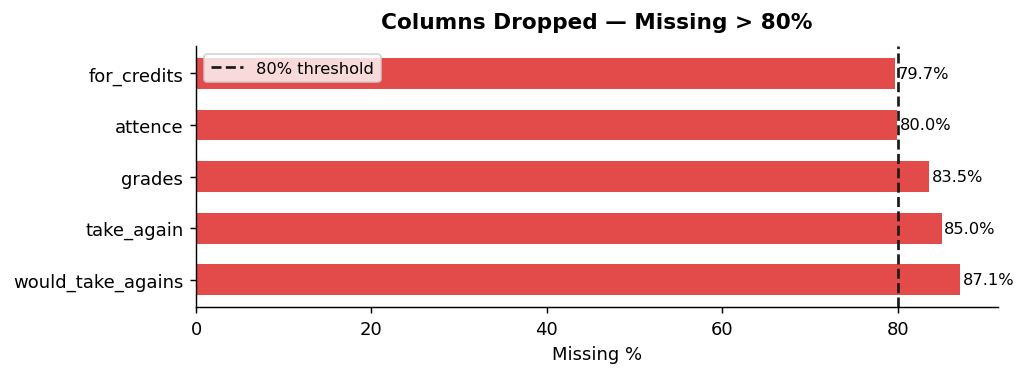


Dropped 5 columns
Shape: (20000, 40)


In [86]:
#DROP HIGH-MISSING COLUMNS 
# Decision rule: if a column has >80% null values, DROP it.
# Rationale: imputing 80%+ means we are inventing 16,000+ values.
# Any model trained on such a column learns from our fabrication, not data.

missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 79].sort_values(ascending=False)

print("Columns with >79% missing values:")
print("-" * 45)
for col, pct in high_missing.items():
    print(f"  {col:<28} {pct:.1f}% missing")

# Visualise
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(high_missing.index, high_missing.values,
        color='#E24B4A', height=0.6, edgecolor='none')
ax.axvline(80, color='#1a1a18', linestyle='--', linewidth=1.5,
           label='80% threshold')
for i, (col, val) in enumerate(high_missing.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Columns Dropped — Missing > 80%', fontweight='bold', pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../charts/01_high_missing_cols.png', dpi=150, bbox_inches='tight')
plt.show()

df = df.drop(columns=high_missing.index.tolist())
print(f"\nDropped {len(high_missing)} columns")
print(f"Shape: {df.shape}")


---
####  Drop Irrelevant / Low-Signal Columns
*Demographics not used in the NLP pipeline. tag_professor is 44% missing and its signal is already captured by the 20 structured binary tag columns.*

In [87]:
# ─── CELL 6: DROP IRRELEVANT COLUMNS ────────────────────────────────────────
# Columns dropped and why:
# gender          : mostly 'unknown'. Not used anywhere in the NLP or clustering
#                   pipeline described in the project document.
# race            : not used in any model in the pipeline.
# asian/hispanic/nh_black/nh_white : race proportion columns. Same reason.

IRRELEVANT_COLS = [ 'gender', 'race',
                   'asian', 'hispanic', 'nh_black', 'nh_white']

print("Dropping irrelevant/low-signal columns:")
for col in IRRELEVANT_COLS:
    if col in df.columns:
        miss = df[col].isnull().sum()
        print(f"  {col:<28} (nulls: {miss:,})")

df = df.drop(columns=[c for c in IRRELEVANT_COLS if c in df.columns])
print(f"\nShape: {df.shape}")
print(f"\nRemaining columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


Dropping irrelevant/low-signal columns:
  gender                       (nulls: 0)
  race                         (nulls: 0)
  asian                        (nulls: 0)
  hispanic                     (nulls: 0)
  nh_black                     (nulls: 0)
  nh_white                     (nulls: 0)

Shape: (20000, 34)

Remaining columns (34):
   1. department_name
   2. year_since_first_review
   3. star_rating
   4. diff_index
   5. tag_professor
   6. num_student
   7. post_date
   8. student_star
   9. student_difficult
  10. help_useful
  11. help_not_useful
  12. comments
  13. word_comment
  14. gives_good_feedback
  15. caring
  16. respected
  17. participation_matters
  18. clear_grading_criteria
  19. skip_class
  20. amazing_lectures
  21. inspirational
  22. tough_grader
  23. hilarious
  24. get_ready_to_read
  25. lots_of_homework
  26. accessible_outside_class
  27. lecture_heavy
  28. extra_credit
  29. graded_by_few_things
  30. group_projects
  31. test_heavy
  32. so_many_pa